In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('Final19_SW_CleanedSurvey.csv')
df1 = pd.read_parquet('CA_baseline_tmy_metadata_and_annual_results.parquet')

/var/folders/tc/d3pbrftn5gx6cgyp81m2gbkm0000gn/T/ipykernel_68165/161544207.py:1: DtypeWarning: Columns (535,537) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Final19_SW_CleanedSurvey.csv')


In [3]:
df = df.sort_values(by = 'CZT24', ascending = True)

In [4]:

# Explore electricity consumption by climate zone
def analyze_by_climate_zone(df, consumption_col, zone_col):
    # Basic statistics by zone
    zone_stats = df.groupby(zone_col)[consumption_col].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    print("\nElectricity consumption statistics by climate zone:")
    print(zone_stats)
    
    # Create distribution plots
    plt.figure(figsize=(12, 8))
    
    # Boxplot
    plt.subplot(2, 2, 1)
    sns.boxplot(x=zone_col, y=consumption_col, data=df)
    plt.title('Electricity Consumption by Climate Zone')
    plt.xticks(rotation=45)
    
    # Violin plot
    plt.subplot(2, 2, 2)
    sns.violinplot(x=zone_col, y=consumption_col, data=df)
    plt.title('Distribution of Electricity Consumption')
    plt.xticks(rotation=45)
    
    # Histogram for all zones
    plt.subplot(2, 2, 3)
    sns.histplot(data=df, x=consumption_col, hue=zone_col, element="step", common_norm=False, kde=True)
    plt.title('Histogram of Electricity Consumption')
    
    # KDE plot
    plt.subplot(2, 2, 4)
    sns.kdeplot(data=df, x=consumption_col, hue=zone_col, fill=True, common_norm=False, alpha=.5)
    plt.title('KDE of Electricity Consumption')
    
    plt.tight_layout()
    plt.savefig('electricity_consumption_distribution.png')
    plt.show()
    
    return zone_stats

# Advanced analysis: compare distributions statistically
def compare_distributions(df, consumption_col, zone_col):
    zones = df[zone_col].unique()
    if len(zones) < 2:
        print("Need at least two climate zones to compare distributions")
        return
    
    print("\nStatistical tests for distribution differences:")
    for i in range(len(zones)):
        for j in range(i+1, len(zones)):
            zone1, zone2 = zones[i], zones[j]
            sample1 = df[df[zone_col] == zone1][consumption_col].dropna()
            sample2 = df[df[zone_col] == zone2][consumption_col].dropna()
            
            # Perform Kolmogorov-Smirnov test
            ks_stat, ks_p = stats.ks_2samp(sample1, sample2)
            print(f"\nComparing {zone1} vs {zone2}:")
            print(f"Kolmogorov-Smirnov test: stat={ks_stat:.4f}, p={ks_p:.4f}")
            if ks_p < 0.05:
                print("  The distributions are significantly different")
            else:
                print("  No significant difference detected in distributions")
            
            # Mann-Whitney U test for comparing medians
            mw_stat, mw_p = stats.mannwhitneyu(sample1, sample2, alternative='two-sided')
            print(f"Mann-Whitney U test: stat={mw_stat:.4f}, p={mw_p:.4f}")
            if mw_p < 0.05:
                print("  The median values are significantly different")
            else:
                print("  No significant difference detected in medians")

# # Main function
# def main():
#     file_path = input("Enter the path to your data file: ")
#     df = load_data(file_path)
    
#     if df is not None:
#         # Display column names to help the user identify the correct columns
#         print("\nAvailable columns:")
#         for i, col in enumerate(df.columns):
#             print(f"{i}: {col}")
        
#         consumption_col = input("\nEnter the name of the electricity consumption column: ")
#         zone_col = input("Enter the name of the climate zone column: ")
        
#         if consumption_col in df.columns and zone_col in df.columns:
#             # Basic data overview
#             print("\nData overview:")
#             print(df[[consumption_col, zone_col]].describe())
            
#             # Analyze by climate zone
#             zone_stats = analyze_by_climate_zone(df, consumption_col, zone_col)
            
#             # Ask if user wants to perform advanced analysis
#             do_advanced = input("\nDo you want to perform statistical comparison of distributions? (y/n): ")
#             if do_advanced.lower() == 'y':
#                 compare_distributions(df, consumption_col, zone_col)
            
#             # Save results to CSV
#             zone_stats.to_csv('climate_zone_stats.csv')
#             print("\nResults saved to 'climate_zone_stats.csv'")
#         else:
#             print("One or both of the specified columns do not exist in the dataset.")

# if __name__ == "__main__":
#     main()


Electricity consumption statistics by climate zone:
       count          mean       median          std          min  \
CZT24                                                               
1        320   5915.409875  5275.570707  2986.099136  1214.524126   
2       1549   6373.522922  5622.345688  3451.103045  1307.355376   
3       4836   4831.459640  4287.875290  2317.763290  1043.083901   
4       2170   5797.339459  5242.664064  2764.164095  1071.324503   
5        514   5110.342128  4611.814122  2559.897671  1257.438481   
6       3674   5360.949473  4675.656247  2736.906928  1102.979821   
7       3297   4859.450651  4232.151581  2373.088012   720.233453   
8       3650   5591.365497  4941.699856  2745.454796  1211.468616   
9       4628   6194.000247  5396.563516  3302.414829  1175.985684   
10      3633   6925.937832  6238.465079  3302.228292  1488.677626   
11      1298   8456.447063  7729.961163  4159.122368  2013.433055   
12      5835   7804.886763  7147.798439  3566.1069

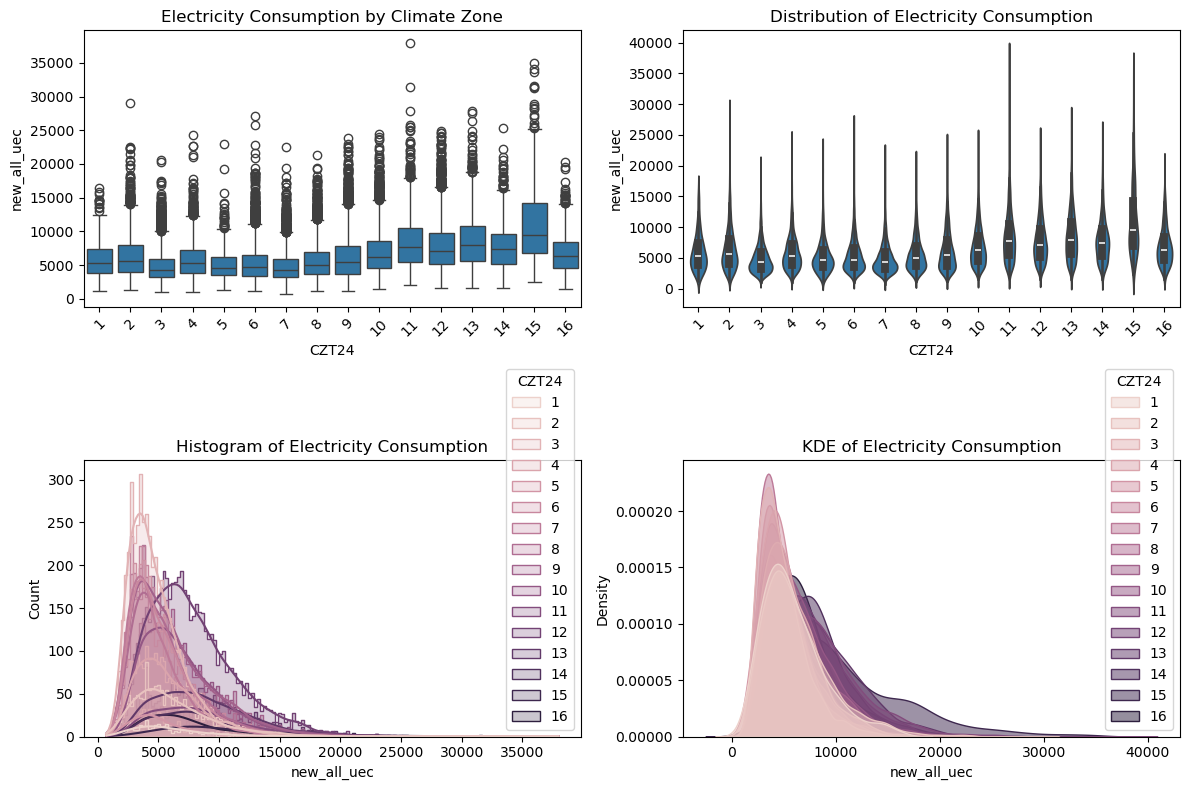

KeyError: False

In [7]:
analyze_by_climate_zone(df, 'new_all_uec', 'CZT24')['CZT24' == 16]

In [6]:
zone_col = 'CZT24'
consumption_col = 'new_all_uec'
zone_stats = df.groupby(zone_col)[consumption_col].agg(['count', 'mean', 'median', 'std', 'min', 'max'])


In [7]:
zone_stats

,count,mean,median,std,min,max
CZT24,,,,,,
1,320,5915.409875,5275.570708,2986.099136,1214.524126,16464.91642
2,1549,6373.522922,5622.345688,3451.103045,1307.355376,29093.22968
3,4836,4831.459641,4287.875290,2317.763290,1043.083901,20579.44336
4,2170,5797.339459,5242.664064,2764.164095,1071.324503,24367.25020
5,514,5110.342128,4611.814122,2559.897671,1257.438481,22898.25999
6,3674,5360.949473,4675.656247,2736.906928,1102.979821,27101.80414
7,3297,4859.450651,4232.151581,2373.088013,720.233453,22463.67576
8,3650,5591.365497,4941.699856,2745.454796,1211.468616,21290.80378
9,4628,6194.000247,5396.563516,3302.414830,1175.985684,23906.24921


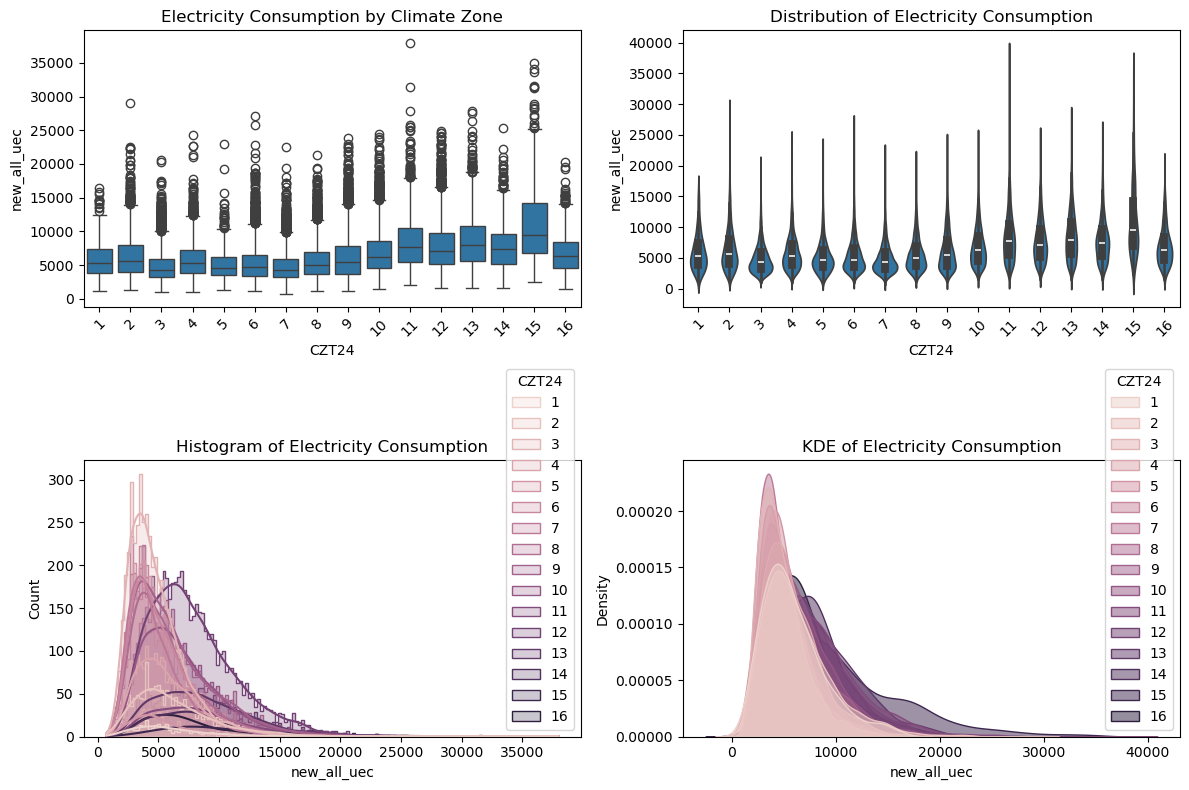

In [5]:
# Create distribution plots
plt.figure(figsize=(12, 8))

# Boxplot
plt.subplot(2, 2, 1)
sns.boxplot(x=zone_col, y=consumption_col, data=df)
plt.title('Electricity Consumption by Climate Zone')
plt.xticks(rotation=45)

# Violin plot
plt.subplot(2, 2, 2)
sns.violinplot(x=zone_col, y=consumption_col, data=df)
plt.title('Distribution of Electricity Consumption')
plt.xticks(rotation=45)

# Histogram for all zones
plt.subplot(2, 2, 3)
sns.histplot(data=df, x=consumption_col, hue=zone_col, element="step", common_norm=False, kde=True)
plt.title('Histogram of Electricity Consumption')

# KDE plot
plt.subplot(2, 2, 4)
sns.kdeplot(data=df, x=consumption_col, hue=zone_col, fill=True, common_norm=False, alpha=.5)
plt.title('KDE of Electricity Consumption')

plt.tight_layout()
#plt.savefig('electricity_consumption_distribution.png')
plt.show()


In [9]:
zone_col = 'in.cec_climate_zone'
consumption_col = 'out.electricity.total.energy_consumption.kwh'
df1[zone_col] = df1[zone_col].astype(int)
df1 = df1.sort_values(by = zone_col, ascending = True)
zone_stats1 = df1.groupby(zone_col)[consumption_col].agg(['count', 'mean', 'median', 'std', 'min', 'max'])


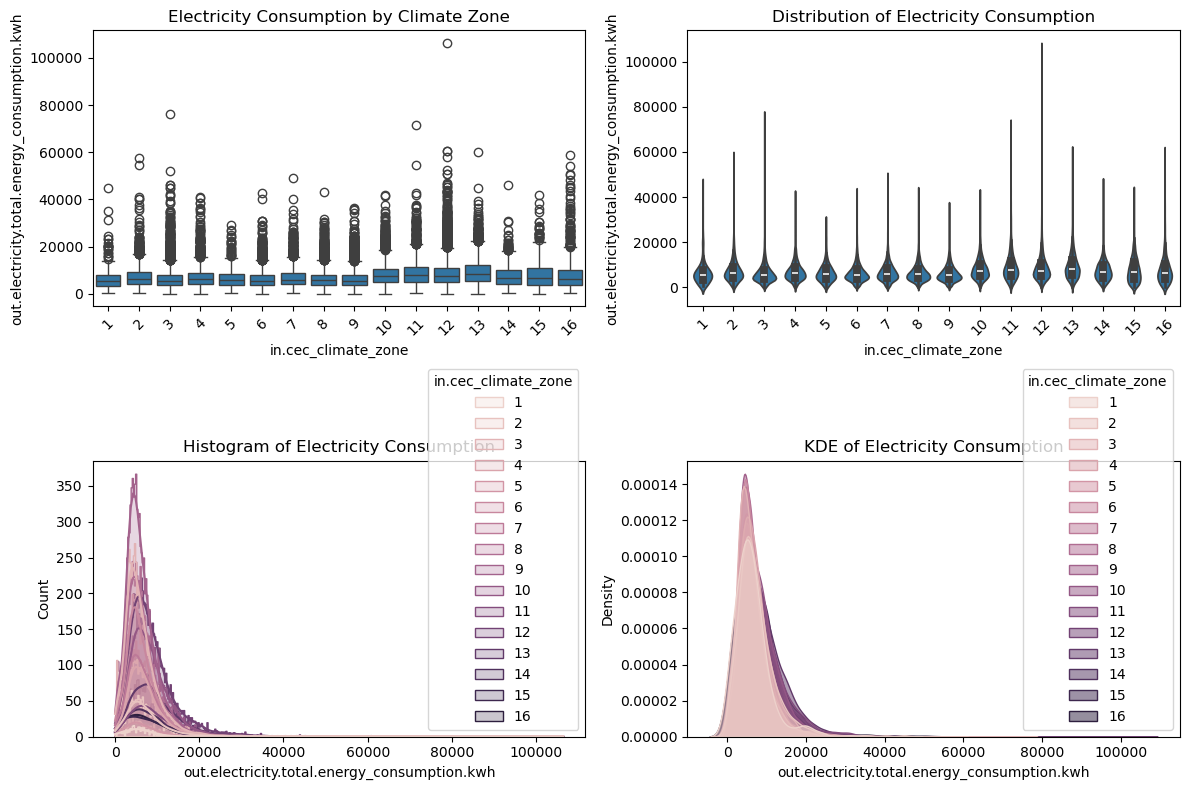

In [10]:
# Create distribution plots
plt.figure(figsize=(12, 8))

# Boxplot
plt.subplot(2, 2, 1)
sns.boxplot(x=zone_col, y=consumption_col, data=df1)
plt.title('Electricity Consumption by Climate Zone')
plt.xticks(rotation=45)

# Violin plot
# plt.subplot(2, 2, 2)
# sns.violinplot(x=zone_col, y=consumption_col, data=df1)
# plt.title('Distribution of Electricity Consumption')
# plt.xticks(rotation=45)

# # Histogram for all zones
# plt.subplot(2, 2, 3)
# sns.histplot(data=df1, x=consumption_col, hue=zone_col, element="step", common_norm=False, kde=True)
# plt.title('Histogram of Electricity Consumption')

# # KDE plot
# plt.subplot(2, 2, 4)
# sns.kdeplot(data=df1, x=consumption_col, hue=zone_col, fill=True, common_norm=False, alpha=.5)
# plt.title('KDE of Electricity Consumption')

plt.tight_layout()
#plt.savefig('electricity_consumption_distribution.png')
plt.show()


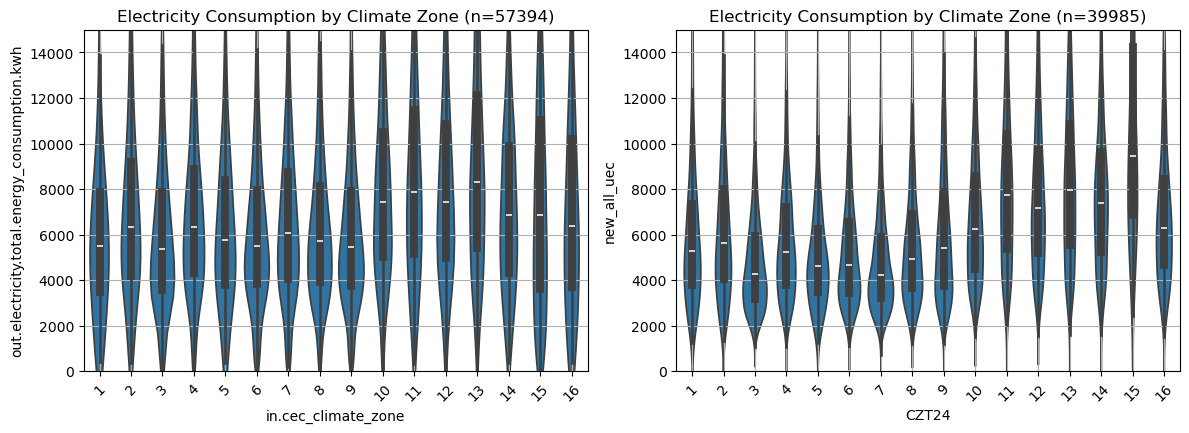

In [14]:
plt.figure(figsize=(12, 8))

# Boxplot
plt.subplot(2, 2, 1)
sns.violinplot(x='in.cec_climate_zone', y='out.electricity.total.energy_consumption.kwh', data=df1)
plt.title(f'Electricity Consumption by Climate Zone (n={len(df1)})')
plt.xticks(rotation=45)
plt.ylim(0,15000)
plt.grid()

plt.subplot(2, 2, 2)
sns.violinplot(x='CZT24', y='new_all_uec', data=df)
plt.title(f'Electricity Consumption by Climate Zone (n={len(df)})')
plt.xticks(rotation=45)
plt.ylim(0,15000)
plt.grid()

# Violin plot
# plt.subplot(2, 2, 2)
# sns.violinplot(x=zone_col, y=consumption_col, data=df1)
# plt.title('Distribution of Electricity Consumption')
# plt.xticks(rotation=45)

# # Histogram for all zones
# plt.subplot(2, 2, 3)
# sns.histplot(data=df1, x=consumption_col, hue=zone_col, element="step", common_norm=False, kde=True)
# plt.title('Histogram of Electricity Consumption')

# # KDE plot
# plt.subplot(2, 2, 4)
# sns.kdeplot(data=df1, x=consumption_col, hue=zone_col, fill=True, common_norm=False, alpha=.5)
# plt.title('KDE of Electricity Consumption')

plt.tight_layout()
#plt.savefig('electricity_consumption_distribution.png')
plt.show()


In [29]:
zone_stats1.astype(int)

,count,mean,median,std,min,max
in.cec_climate_zone,,,,,,
1,359,6394,5500,5118,383,44905
2,1663,7390,6348,5141,365,57680
3,6410,6323,5345,4508,0,76423
4,3015,7175,6327,4428,10,41109
5,628,6583,5752,4268,370,29061
6,4810,6279,5510,3800,0,42548
7,3485,6814,6047,4149,186,49137
8,6097,6465,5723,3759,60,43087
9,8815,6222,5466,3715,0,36545


In [42]:
zone_stats.astype(int)

,count,mean,median,std,min,max
CZT24,,,,,,
1,320,5915,5275,2986,1214,16464
2,1549,6373,5622,3451,1307,29093
3,4836,4831,4287,2317,1043,20579
4,2170,5797,5242,2764,1071,24367
5,514,5110,4611,2559,1257,22898
6,3674,5360,4675,2736,1102,27101
7,3297,4859,4232,2373,720,22463
8,3650,5591,4941,2745,1211,21290
9,4628,6194,5396,3302,1175,23906


In [15]:
def calculate_zone_scaling_factors(sim_df, survey_df, 
                                   sim_consumption_col, survey_consumption_col,
                                   sim_zone_col, survey_zone_col):
    """
    Calculate scaling factors by climate zone to adjust simulated data to match survey data.
    
    Parameters:
    -----------
    sim_df : pandas DataFrame
        DataFrame containing the simulated data
    survey_df : pandas DataFrame
        DataFrame containing the survey data
    sim_consumption_col : str
        Column name for energy consumption in sim_df
    survey_consumption_col : str
        Column name for energy consumption in survey_df
    sim_zone_col : str
        Column name for climate zone in sim_df
    survey_zone_col : str
        Column name for climate zone in survey_df
        
    Returns:
    --------
    scaling_factors : dict
        Dictionary mapping climate zones to scaling factors
    """
    # Calculate mean consumption by zone for each dataset
    sim_zone_means = sim_df.groupby(sim_zone_col)[sim_consumption_col].mean()
    survey_zone_means = survey_df.groupby(survey_zone_col)[survey_consumption_col].mean()
    
    # Get unique climate zones
    zones = np.unique(np.concatenate([sim_df[sim_zone_col].unique(), 
                                      survey_df[survey_zone_col].unique()]))
    
    # Calculate scaling factors
    scaling_factors = {}
    for zone in zones:
        # Check if zone exists in both datasets
        if zone in sim_zone_means.index and zone in survey_zone_means.index:
            # Calculate ratio of survey mean to simulation mean
            scaling_factors[zone] = survey_zone_means[zone] / sim_zone_means[zone]
        else:
            print(f"Warning: Climate zone '{zone}' not found in both datasets")
            # Use overall average scaling if a zone is missing from one dataset
            if zone in sim_zone_means.index:
                scaling_factors[zone] = survey_zone_means.mean() / sim_zone_means.mean()
            else:
                scaling_factors[zone] = 1.0  # Default to no scaling
    
    return scaling_factors


In [16]:
scaling_factors = calculate_zone_scaling_factors(df1, df, 
                        'out.electricity.total.energy_consumption.kwh', 'new_all_uec',
                               'in.cec_climate_zone', 'CZT24')
                               

In [17]:
def handle_outliers_and_add_scaling(sim_df, scaling_factors, zone_col, consumption_col, 
                                    method='winsorize', limits=(0.05, 0.95), max_scale=3.0):
    """
    Add scaling factors to annual simulated data with outlier handling.
    
    Parameters:
    -----------
    sim_df : pandas DataFrame
        DataFrame containing the simulated annual data
    scaling_factors : dict
        Dictionary mapping climate zones to scaling factors
    zone_col : str
        Column name for climate zone in sim_df
    consumption_col : str, default='total'
        Column name for the annual consumption to scale
    method : str, default='winsorize'
        Method for handling outliers:
        - 'winsorize': Cap extreme values at specified percentiles
        - 'cap_scaling': Cap the scaling factors directly
        - 'remove': Remove outliers (returns smaller dataframe)
        - 'log_transform': Apply log transform before scaling
    limits : tuple, default=(0.05, 0.95)
        Percentile limits for winsorizing or outlier detection
    max_scale : float, default=3.0
        Maximum allowed scaling factor when using 'cap_scaling'
        
    Returns:
    --------
    result_df : pandas DataFrame
        DataFrame with scaling factors and scaled consumption added
    """
    import numpy as np
    from scipy import stats
    
    # Create a copy to avoid modifying the original
    result_df = sim_df.copy()
    
    # Add scaling factor column based on climate zone
    result_df['scaling_factor'] = result_df[zone_col].map(scaling_factors)
    
    # Handle missing values (zones without scaling factors)
    missing_mask = result_df['scaling_factor'].isna()
    if missing_mask.any():
        missing_zones = result_df.loc[missing_mask, zone_col].unique()
        print(f"Warning: No scaling factors for zones: {missing_zones}")
        result_df['scaling_factor'].fillna(1.0, inplace=True)
    
    # Handle outliers in the consumption data
    if method == 'winsorize':
        # Handle outliers by climate zone
        for zone in result_df[zone_col].unique():
            zone_mask = (result_df[zone_col] == zone)
            
            # Skip zones with very few buildings
            if zone_mask.sum() < 5:
                print(f"Skipping outlier treatment for zone '{zone}' with only {zone_mask.sum()} buildings")
                continue
            
            # Get consumption values for this zone
            zone_values = result_df.loc[zone_mask, consumption_col].values
            
            # Calculate percentile thresholds for this zone
            lower_limit = np.percentile(zone_values, limits[0] * 100)
            upper_limit = np.percentile(zone_values, limits[1] * 100)
            
            # Winsorize the data
            result_df.loc[zone_mask & (result_df[consumption_col] < lower_limit), consumption_col] = lower_limit
            result_df.loc[zone_mask & (result_df[consumption_col] > upper_limit), consumption_col] = upper_limit
            
            print(f"Zone '{zone}': Winsorized values below {lower_limit:.2f} and above {upper_limit:.2f}")
    
    elif method == 'cap_scaling':
        # Apply scaling factors but cap them at max_scale
        print(f"Capping scaling factors at {max_scale}")
        result_df['scaling_factor'] = result_df['scaling_factor'].clip(1/max_scale, max_scale)
    
    elif method == 'remove':
        # Remove outliers based on consumption (not scaling factor)
        for zone in result_df[zone_col].unique():
            zone_mask = (result_df[zone_col] == zone)
            
            # Skip zones with very few buildings
            if zone_mask.sum() < 5:
                continue
                
            # Get consumption values for this zone
            zone_values = result_df.loc[zone_mask, consumption_col].values
            
            # Calculate percentile thresholds
            lower_limit = np.percentile(zone_values, limits[0] * 100)
            upper_limit = np.percentile(zone_values, limits[1] * 100)
            
            # Create outlier mask
            outlier_mask = (result_df[consumption_col] < lower_limit) | (result_df[consumption_col] > upper_limit)
            outlier_count = (zone_mask & outlier_mask).sum()
            
            if outlier_count > 0:
                print(f"Removing {outlier_count} outliers from zone '{zone}'")
                # Remove outliers
                result_df = result_df[~(zone_mask & outlier_mask)]
    
    elif method == 'log_transform':
        # Log transform consumption before scaling
        # Add a small constant to handle zeros
        epsilon = 1.0  # small constant to add before log transform
        result_df['log_' + consumption_col] = np.log(result_df[consumption_col] + epsilon)
        
        # Apply scaling in log space, then transform back
        result_df['scaled_log_' + consumption_col] = result_df['log_' + consumption_col] + np.log(result_df['scaling_factor'])
        result_df['scaled_' + consumption_col] = np.exp(result_df['scaled_log_' + consumption_col]) - epsilon
        
        # No need for the final calculation step below
        return result_df
    
    # Calculate scaled consumption
    if consumption_col in result_df.columns:
        result_df['scaled_' + consumption_col] = result_df[consumption_col] * result_df['scaling_factor']
    else:
        print(f"Warning: Consumption column '{consumption_col}' not found in dataframe")
    
    return result_df

In [18]:
df_scaled = handle_outliers_and_add_scaling(df1, scaling_factors, 'in.cec_climate_zone', 'out.electricity.total.energy_consumption.kwh', 
                                           method='winsorize', limits=(0.01, 0.99), max_scale=3.0)

Zone '1': Winsorized values below 444.31 and above 23818.38
Zone '2': Winsorized values below 707.37 and above 24016.60
Zone '3': Winsorized values below 440.51 and above 22132.15
Zone '4': Winsorized values below 556.96 and above 22832.74
Zone '5': Winsorized values below 478.11 and above 22470.58
Zone '6': Winsorized values below 455.14 and above 18616.85
Zone '7': Winsorized values below 433.45 and above 21134.48
Zone '8': Winsorized values below 653.13 and above 18913.31
Zone '9': Winsorized values below 461.75 and above 18617.77
Zone '10': Winsorized values below 717.20 and above 23052.97
Zone '11': Winsorized values below 809.47 and above 30435.58
Zone '12': Winsorized values below 732.00 and above 30005.70
Zone '13': Winsorized values below 770.37 and above 26759.01
Zone '14': Winsorized values below 597.38 and above 19981.28
Zone '15': Winsorized values below 418.14 and above 25468.46
Zone '16': Winsorized values below 402.65 and above 36129.86


In [15]:
df_scaled.to_parquet('CA_baseline_metadata_rescaled.parquet')

In [21]:
df_scaled.head(5).to_csv('CA_baseline_metadata_rescaled_head.csv')

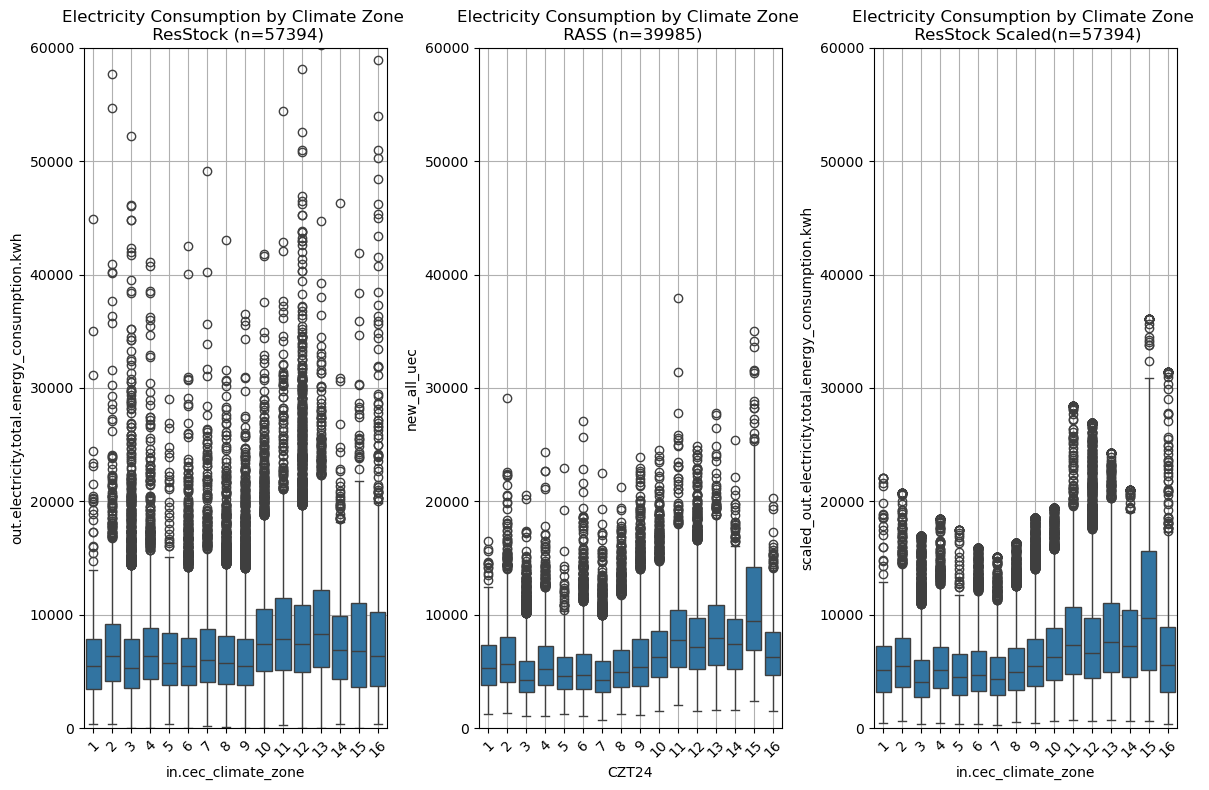

In [19]:
plt.figure(figsize=(12, 8))

# Boxplot
plt.subplot(1, 3, 1)
sns.boxplot(x='in.cec_climate_zone', y='out.electricity.total.energy_consumption.kwh', data=df1)
plt.title(f'Electricity Consumption by Climate Zone \n ResStock (n={len(df1)})')
plt.xticks(rotation=45)
plt.ylim(0,60000)
plt.grid()

plt.subplot(1, 3, 2)
sns.boxplot(x='CZT24', y='new_all_uec', data=df)
plt.title(f'Electricity Consumption by Climate Zone \n RASS (n={len(df)})')
plt.xticks(rotation=45)
plt.ylim(0,60000)
plt.grid()

plt.subplot(1, 3, 3)
sns.boxplot(x='in.cec_climate_zone', y='scaled_out.electricity.total.energy_consumption.kwh', data=df_scaled)
plt.title(f'Electricity Consumption by Climate Zone \n ResStock Scaled(n={len(df_scaled)})')
plt.xticks(rotation=45)
plt.ylim(0,60000)
plt.grid()

# # Violin plot
# plt.subplot(2, 2, 2)
# sns.violinplot(x=zone_col, y=consumption_col, data=df1)
# plt.title('Distribution of Electricity Consumption')
# plt.xticks(rotation=45)

# # Histogram for all zones
# plt.subplot(2, 2, 3)
# sns.histplot(data=df1, x=consumption_col, hue=zone_col, element="step", common_norm=False, kde=True)
# plt.title('Histogram of Electricity Consumption')

# # KDE plot
# plt.subplot(2, 2, 4)
# sns.kdeplot(data=df1, x=consumption_col, hue=zone_col, fill=True, common_norm=False, alpha=.5)
# plt.title('KDE of Electricity Consumption')

plt.tight_layout()
#plt.savefig('electricity_consumption_distribution.png')
plt.show()


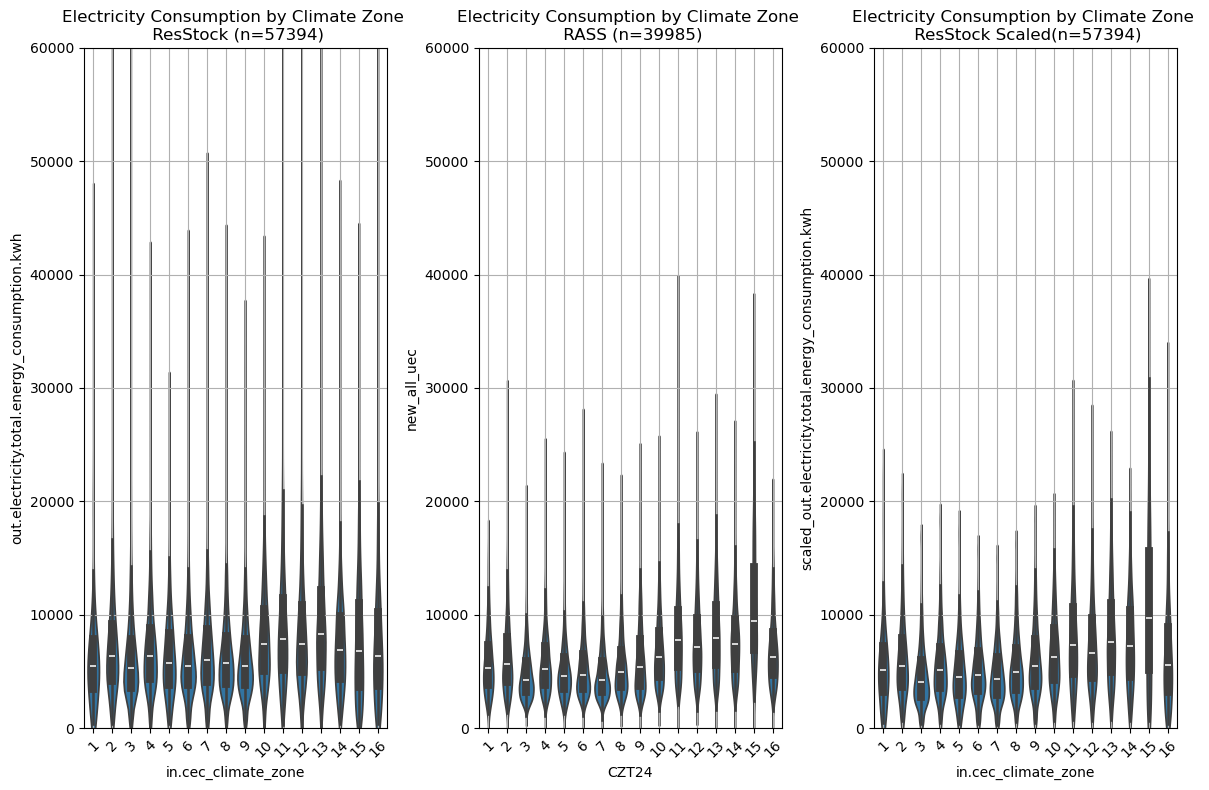

In [20]:
plt.figure(figsize=(12, 8))

# Boxplot
plt.subplot(1, 3, 1)
sns.violinplot(x='in.cec_climate_zone', y='out.electricity.total.energy_consumption.kwh', data=df1)
plt.title(f'Electricity Consumption by Climate Zone \n ResStock (n={len(df1)})')
plt.xticks(rotation=45)
plt.ylim(0,60000)
plt.grid()

plt.subplot(1, 3, 2)
sns.violinplot(x='CZT24', y='new_all_uec', data=df)
plt.title(f'Electricity Consumption by Climate Zone \n RASS (n={len(df)})')
plt.xticks(rotation=45)
plt.ylim(0,60000)
plt.grid()

plt.subplot(1, 3, 3)
sns.violinplot(x='in.cec_climate_zone', y='scaled_out.electricity.total.energy_consumption.kwh', data=df_scaled)
plt.title(f'Electricity Consumption by Climate Zone \n ResStock Scaled(n={len(df_scaled)})')
plt.xticks(rotation=45)
plt.ylim(0,60000)
plt.grid()

# # Violin plot
# plt.subplot(2, 2, 2)
# sns.violinplot(x=zone_col, y=consumption_col, data=df1)
# plt.title('Distribution of Electricity Consumption')
# plt.xticks(rotation=45)

# # Histogram for all zones
# plt.subplot(2, 2, 3)
# sns.histplot(data=df1, x=consumption_col, hue=zone_col, element="step", common_norm=False, kde=True)
# plt.title('Histogram of Electricity Consumption')

# # KDE plot
# plt.subplot(2, 2, 4)
# sns.kdeplot(data=df1, x=consumption_col, hue=zone_col, fill=True, common_norm=False, alpha=.5)
# plt.title('KDE of Electricity Consumption')

plt.tight_layout()
#plt.savefig('electricity_consumption_distribution.png')
plt.show()


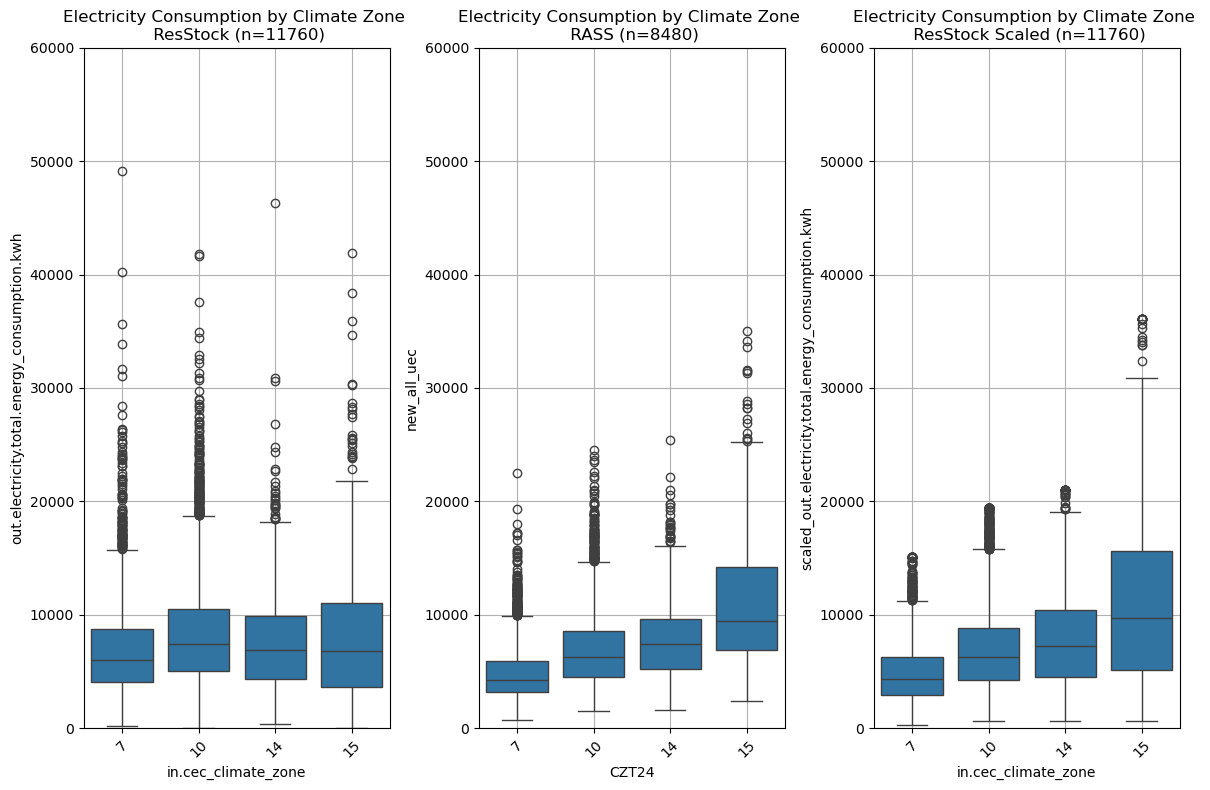

In [22]:
zones = [7, 10, 14, 15]

df1_filt = df1[df1['in.cec_climate_zone'].isin(zones)]
df_filt = df[df['CZT24'].isin(zones)]
df_scaled_filt = df_scaled[df_scaled['in.cec_climate_zone'].isin(zones)]

plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1)
sns.boxplot(x='in.cec_climate_zone', y='out.electricity.total.energy_consumption.kwh', 
               data=df1_filt, order=zones)
plt.title(f'Electricity Consumption by Climate Zone \n ResStock (n={len(df1_filt)})')
plt.xticks(rotation=45)
plt.ylim(0, 60000)
plt.grid()

plt.subplot(1, 3, 2)
sns.boxplot(x='CZT24', y='new_all_uec', data=df_filt, order=zones)
plt.title(f'Electricity Consumption by Climate Zone \n RASS (n={len(df_filt)})')
plt.xticks(rotation=45)
plt.ylim(0, 60000)
plt.grid()

plt.subplot(1, 3, 3)
sns.boxplot(x='in.cec_climate_zone', y='scaled_out.electricity.total.energy_consumption.kwh', 
               data=df_scaled_filt, order=zones)
plt.title(f'Electricity Consumption by Climate Zone \n ResStock Scaled (n={len(df_scaled_filt)})')
plt.xticks(rotation=45)
plt.ylim(0, 60000)
plt.grid()

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

def analyze_income_energy_relationship(survey_df, energy_col, income_col, zone_col,
                                       income_bins=None, log_transform=True):
    """
    Analyze the relationship between income and energy consumption by climate zone.
    
    Parameters:
    -----------
    survey_df : pandas DataFrame
        Survey data containing income and energy consumption
    energy_col : str
        Column name for energy consumption
    income_col : str
        Column name for income
    zone_col : str
        Column name for climate zone
    income_bins : list, optional
        List of income bin edges for categorization. If None, quartiles are used.
    log_transform : bool, default=True
        Whether to use log transformation for regression analysis
        
    Returns:
    --------
    results : dict
        Dictionary containing analysis results
    """
    # Make a copy to avoid modifying the original
    df = survey_df.copy()
    
    # Check for missing values
    missing_energy = df[energy_col].isna().sum()
    missing_income = df[income_col].isna().sum()
    
    if missing_energy > 0 or missing_income > 0:
        print(f"Warning: Found {missing_energy} missing values in {energy_col}")
        print(f"Warning: Found {missing_income} missing values in {income_col}")
        print("Removing rows with missing values for this analysis")
        df = df.dropna(subset=[energy_col, income_col])
    
    # Basic statistics by climate zone
    zone_stats = df.groupby(zone_col).agg({
        energy_col: ['count', 'mean', 'median', 'std'],
        income_col: ['mean', 'median', 'std']
    })
    
    print("\n=== Energy Consumption and Income by Climate Zone ===")
    print(zone_stats)
    
    # Create income bins if not provided
    if income_bins is None:
        # Use quartiles for income bins
        income_bins = [
            df[income_col].min(),
            df[income_col].quantile(0.25),
            df[income_col].quantile(0.5),
            df[income_col].quantile(0.75),
            df[income_col].max()
        ]
    
    # Create income group categorical variable
    income_labels = [f"Q{i+1}" for i in range(len(income_bins)-1)]
    df['income_group'] = pd.cut(df[income_col], bins=income_bins, labels=income_labels)
    
    # Calculate correlation by climate zone
    correlations = {}
    for zone in df[zone_col].unique():
        zone_df = df[df[zone_col] == zone]
        correlations[zone] = {
            'pearson': stats.pearsonr(zone_df[income_col], zone_df[energy_col]),
            'spearman': stats.spearmanr(zone_df[income_col], zone_df[energy_col])
        }
    
    print("\n=== Correlation between Income and Energy Consumption ===")
    for zone, corr in correlations.items():
        print(f"\nClimate Zone: {zone}")
        print(f"Pearson correlation: r={corr['pearson'][0]:.4f}, p={corr['pearson'][1]:.4f}")
        print(f"Spearman correlation: r={corr['spearman'][0]:.4f}, p={corr['spearman'][1]:.4f}")
    
    # Create visualizations
    plt.figure(figsize=(16, 12))
    
    # 1. Scatter plot with regression line for each climate zone
    plt.subplot(2, 2, 1)
    for zone in df[zone_col].unique():
        zone_df = df[df[zone_col] == zone]
        #plt.scatter(zone_df[income_col], zone_df[energy_col], alpha=0.5, label=f"{zone}")
        
        # Add regression line
        x = zone_df[income_col]
        y = zone_df[energy_col]
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        plt.plot(x, p(x), label=f"{zone}")
    
    plt.xlabel('Income')
    plt.ylabel('Energy Consumption')
    plt.title('Income vs. Energy Consumption by Climate Zone')
    plt.legend(loc = 'upper left', ncols =3)
    plt.xlim(0,550000)

    # 2. Box plot of energy consumption by income group and climate zone
    # plt.subplot(2, 2, 2)
    # sns.boxplot(x='income_group', y=energy_col, hue=zone_col, data=df)
    # plt.xlabel('Income Quartile')
    # plt.ylabel('Energy Consumption')
    # plt.title('Energy Consumption by Income Group and Climate Zone')
    
    # # 3. Energy consumption distribution by climate zone
    # plt.subplot(2, 2, 3)
    # for zone in df[zone_col].unique():
    #     zone_df = df[df[zone_col] == zone]
    #     sns.kdeplot(zone_df[energy_col], label=f"{zone}", fill=True, alpha=0.3)
    
    # plt.xlabel('Energy Consumption')
    # plt.title('Energy Consumption Distribution by Climate Zone')
    # plt.legend()
    
    # # 4. Mean energy consumption by income group and climate zone
    # plt.subplot(2, 2, 4)
    # mean_by_group = df.groupby([zone_col, 'income_group'])[energy_col].mean().reset_index()
    # mean_by_group_pivot = mean_by_group.pivot(index='income_group', columns=zone_col, values=energy_col)
    # mean_by_group_pivot.plot(kind='bar')
    
    # plt.xlabel('Income Quartile')
    # plt.ylabel('Mean Energy Consumption')
    # plt.title('Mean Energy Consumption by Income Group and Climate Zone')
    
    # plt.tight_layout()
    # plt.savefig('income_energy_relationship.png')
    # plt.show()
    
    # Regression analysis by climate zone
    regression_results = {}
    for zone in df[zone_col].unique():
        zone_df = df[df[zone_col] == zone]
        
        # Prepare data for regression
        X = zone_df[income_col].values
        y = zone_df[energy_col].values
        
        if log_transform:
            # Log transform to handle non-linearity and heteroscedasticity
            X = np.log1p(X)  # log(1+x) to handle zeros
            y = np.log1p(y)
        
        # Add constant for intercept
        X = sm.add_constant(X)
        
        # Run OLS regression
        model = sm.OLS(y, X).fit()
        
        regression_results[zone] = {
            'model': model,
            'summary': model.summary(),
            'params': model.params,
            'rsquared': model.rsquared,
            'rsquared_adj': model.rsquared_adj,
            'pvalues': model.pvalues
        }
    
    print("\n=== Regression Analysis Results ===")
    for zone, results in regression_results.items():
        print(f"\nClimate Zone: {zone}")
        print(f"R-squared: {results['rsquared']:.4f}")
        print(f"Adjusted R-squared: {results['rsquared_adj']:.4f}")
        
        if log_transform:
            income_coef = results['params'][1]
            print(f"Income coefficient (log-log): {income_coef:.4f}")
            print(f"  Interpretation: 1% increase in income associated with {income_coef:.2f}% change in energy consumption")
        else:
            income_coef = results['params'][1]
            print(f"Income coefficient: {income_coef:.4f}")
            print(f"  Interpretation: $1 increase in income associated with {income_coef:.6f} unit change in energy consumption")
        
        print(f"P-value for income coefficient: {results['pvalues'][1]:.6f}")
    
    # Advanced analysis: Compare income elasticity of energy demand across zones
    if log_transform:
        print("\n=== Income Elasticity of Energy Demand by Climate Zone ===")
        elasticities = {}
        for zone, results in regression_results.items():
            elasticities[zone] = results['params'][1]
        
        elasticity_df = pd.DataFrame({
            'Climate Zone': elasticities.keys(),
            'Income Elasticity': elasticities.values()
        })
        
        print(elasticity_df.sort_values('Income Elasticity', ascending=False))
        
        # Visualize elasticities
        plt.figure(figsize=(10, 6))
        plt.bar(elasticities.keys(), elasticities.values())
        plt.axhline(y=1, color='r', linestyle='--', alpha=0.7, label='Unit Elasticity')
        plt.xlabel('Climate Zone')
        plt.ylabel('Income Elasticity of Energy Demand')
        plt.title('Income Elasticity by Climate Zone')
        plt.legend()
        plt.savefig('income_elasticity_by_zone.png')
        plt.show()
    
    # Group means analysis
    group_means = df.groupby([zone_col, 'income_group'])[energy_col].agg(['mean', 'count', 'std']).reset_index()
    print("\n=== Energy Consumption by Income Group and Climate Zone ===")
    print(group_means)
    
    return {
        'zone_stats': zone_stats,
        'correlations': correlations,
        'regression_results': regression_results,
        'income_bins': income_bins,
        'group_means': group_means
    }

# Example usage:
# results = analyze_income_energy_relationship(
#     survey_df,
#     energy_col='total_energy',
#     income_col='household_income',
#     zone_col='climate_zone',
#     log_transform=True
# )

# Optional: ANOVA test to see if energy consumption differs significantly between income groups
def income_group_anova(survey_df, energy_col, income_col, zone_col, income_bins=None):
    """
    Perform ANOVA test to determine if energy consumption differs significantly between income groups.
    """
    # Prepare data
    df = survey_df.copy().dropna(subset=[energy_col, income_col, zone_col])
    
    # Create income bins if not provided
    if income_bins is None:
        income_bins = [
            df[income_col].min(),
            df[income_col].quantile(0.25),
            df[income_col].quantile(0.5),
            df[income_col].quantile(0.75),
            df[income_col].max()
        ]
    
    # Create income group categorical variable
    income_labels = [f"Q{i+1}" for i in range(len(income_bins)-1)]
    df['income_group'] = pd.cut(df[income_col], bins=income_bins, labels=income_labels)
    
    # Perform ANOVA for each climate zone
    anova_results = {}
    for zone in df[zone_col].unique():
        zone_df = df[df[zone_col] == zone]
        
        # Skip if not enough data
        if len(zone_df) < 10:
            print(f"Skipping ANOVA for zone {zone}: not enough data")
            continue
        
        # Group data
        groups = [zone_df[zone_df['income_group'] == group][energy_col].values 
                 for group in zone_df['income_group'].unique()]
        
        # Remove empty groups
        groups = [g for g in groups if len(g) > 0]
        
        # Perform ANOVA
        f_val, p_val = stats.f_oneway(*groups)
        
        anova_results[zone] = {
            'f_value': f_val,
            'p_value': p_val,
            'significant': p_val < 0.05
        }
    
    print("\n=== ANOVA Results: Energy Consumption Difference Between Income Groups ===")
    for zone, result in anova_results.items():
        print(f"\nClimate Zone: {zone}")
        print(f"F-value: {result['f_value']:.4f}")
        print(f"P-value: {result['p_value']:.4f}")
        if result['significant']:
            print("Result: Significant difference in energy consumption between income groups")
        else:
            print("Result: No significant difference in energy consumption between income groups")
    
    return anova_results

# Example usage:
# anova_results = income_group_anova(
#     survey_df,
#     energy_col='total_energy',
#     income_col='household_income',
#     zone_col='climate_zone'
# )

In [21]:
analyze_income_energy_relationship(survey_df, energy_col, income_col, zone_col,
                                       income_bins=None, log_transform=True)

NameError: name 'survey_df' is not defined

Removing rows with missing values for this analysis

=== Energy Consumption and Income by Climate Zone ===
      new_all_uec                                                 avginc  \
            count          mean       median          std           mean   
CZT24                                                                      
1             320   5915.409875  5275.570707  2986.099136   80346.196859   
2            1549   6373.522922  5622.345688  3451.103045  109176.306815   
3            4836   4831.459640  4287.875290  2317.763290  136240.949139   
4            2170   5797.339459  5242.664064  2764.164095  141788.480501   
5             514   5110.342128  4611.814122  2559.897671  101907.961178   
6            3674   5360.949473  4675.656247  2736.906928  124810.765668   
7            3297   4859.450651  4232.151581  2373.088012  103762.168017   
8            3650   5591.365497  4941.699856  2745.454796   94175.721363   
9            4628   6194.000247  5396.563516  3302.414829

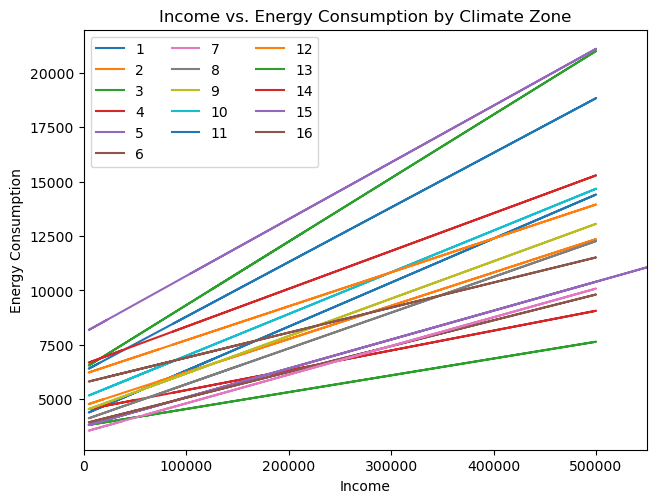

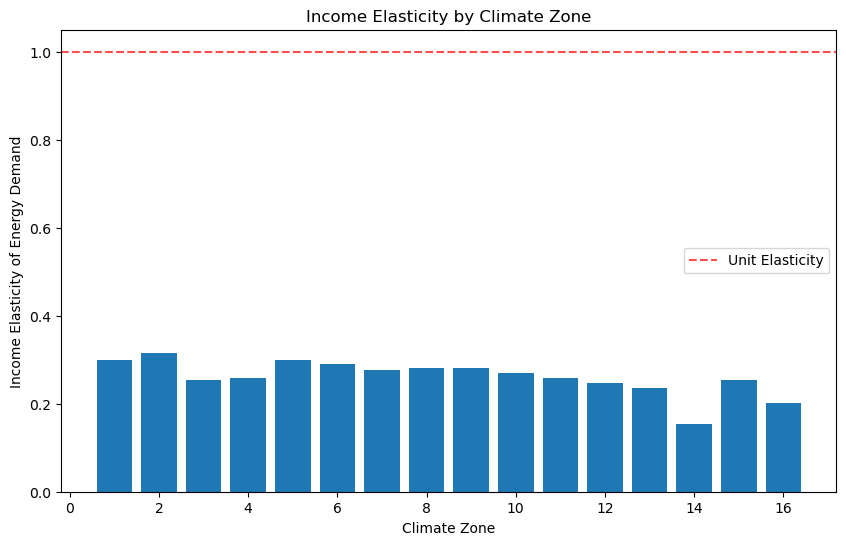


=== Energy Consumption by Income Group and Climate Zone ===
    CZT24 income_group          mean  count          std
0       1           Q1   4744.607305     94  2522.030772
1       1           Q2   5162.214882     96  2323.125209
2       1           Q3   6863.628608     97  2913.792355
3       1           Q4   9808.856311     26  2958.822493
4       2           Q1   4876.950686    330  2802.860207
..    ...          ...           ...    ...          ...
59     15           Q4  16356.011185    134  7089.853003
60     16           Q1   5651.169335    206  2255.212840
61     16           Q2   6084.314901    173  2789.785688
62     16           Q3   7609.810664    206  2808.246117
63     16           Q4   9279.118231    125  3479.084335

[64 rows x 5 columns]


/var/folders/tc/d3pbrftn5gx6cgyp81m2gbkm0000gn/T/ipykernel_60324/2472603336.py:212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby([zone_col, 'income_group'])[energy_col].agg(['mean', 'count', 'std']).reset_index()


{'zone_stats':       new_all_uec                                                 avginc  \
             count          mean       median          std           mean   
 CZT24                                                                      
 1             320   5915.409875  5275.570707  2986.099136   80346.196859   
 2            1549   6373.522922  5622.345688  3451.103045  109176.306815   
 3            4836   4831.459640  4287.875290  2317.763290  136240.949139   
 4            2170   5797.339459  5242.664064  2764.164095  141788.480501   
 5             514   5110.342128  4611.814122  2559.897671  101907.961178   
 6            3674   5360.949473  4675.656247  2736.906928  124810.765668   
 7            3297   4859.450651  4232.151581  2373.088012  103762.168017   
 8            3650   5591.365497  4941.699856  2745.454796   94175.721363   
 9            4628   6194.000247  5396.563516  3302.414829  100784.822528   
 10           3633   6925.937832  6238.465079  3302.228292   9

In [22]:
analyze_income_energy_relationship(df, 'new_all_uec', 'avginc', 'CZT24', None, True)